# Generate C code — `navigate_real_64`, **split across two processors**

`navigate_real` is a `cnn_gru` policy, so unlike `hover_real` it cannot all live on the
flight controller: the depth encoder is ~4.8 M MACs per frame, the recurrent controller
~25 k MACs per step. This notebook cuts the network at the one place where the split is
free — the 64-float projection between the CNN and the GRU — and emits **two**
independent C modules.

```
 companion computer / groundstation            flight controller  (100 Hz)
+------------------------------------+        +--------------------------------------+
| depth 48x64 (m)                    |        | world_state[16]                      |
|   v preprocess (clip, 3/d-0.6,     |        |   v obs[16] = pos-target, vel, rpy,   |
|     4x4 max-pool)  -> 12x16        |        |     omega, W                         |
|   v Conv 2x2 s2 x32   leaky        |        |   v Dense 16->64 (no bias)           |
|   v Conv 3x3 s1 x64   leaky        |        |                                      |
|   v Conv 3x3 s1 x128  leaky        |  img   |  fused = leaky(img_feat + obs_feat)  |
|   v flatten 6144                   | feat   |                                      |
|   v Dense 6144->64      -----------+------->|   v GRUCell(64)   <-- hidden state    |
|                                    | [64]   |   v leaky                            |
|                                    | 10 Hz  |   v Dense 64->4 (no bias)            |
+------------------------------------+        |   v clip[-1,1] -> motor cmds [0,1]   |
                                              +--------------------------------------+
```

**Why this cut and no other.** `img_feat` is the *only* tensor crossing from the CNN into
the recurrent half (`JADS/models/cnn_gru.py:65`): `fused = leaky_relu(img_feat +
obs_feat)`. Everything upstream of it depends solely on the depth image, everything
downstream solely on `img_feat` + `obs` + `hidden`. So the split is exact — no
approximation, no retraining. It is also the narrowest point in the graph: 64 floats,
against 6144 at the flatten or 192 pixels at the pooled image.

**Why it costs nothing in fidelity.** The depth camera already runs at `cam_hz = 10 Hz`
against a 100 Hz control loop, and training modelled that with a zero-order hold on the
*depth image* (`frame_skip = 10`, `JADS/tasks/navigate_real.py:259`). Holding the depth
image for 10 steps and recomputing the CNN each step gives exactly the same `img_feat` as
computing it once and holding *that* for 10 steps. So the FC holding the last received
feature vector between packets **is** the training-time behaviour, not an approximation of
it. The link only has to keep up with the camera, not with the control loop.

The GRU stays on the FC deliberately: it must advance at the full control rate and it
carries the state that makes the policy work, so putting it across a link would turn every
dropped frame into a hole in the recurrence.

**The transport is out of scope.** This notebook emits the two halves and nothing between
them. The companion side hands you `float features[64]`; the FC side takes them through
`nn_set_features()`. Serialising, framing, checksumming and shipping that vector is yours
to write — the tests below drive `nn_set_features()` directly, so what they measure is the
split itself, with a perfect link assumed. The last test then characterises what happens
when the link is *not* perfect, so there is something to size it against.

In [1]:
import os
import sys
import subprocess

import numpy as np

sys.path.insert(0, os.path.abspath('..'))

from JADS.models import make_model
from JADS.tasks import make_env
from JADS.utils.checkpoint import load as load_checkpoint
from JADS.utils.config import load_config

CONFIG_PATH = '../configs/train/navigate_real.yaml'

# Which checkpoint the config produced. Leave as None to follow the config's own
# logging.checkpoint_path — typing it separately is how a config and a checkpoint
# from two different runs end up generating C that looks fine and has the wrong
# constants baked into it. Only the weights would be right: the architecture is
# asserted against the checkpoint below, but cam_hz, the target box and the loss
# weights are read from the config and nothing cross-checks them.
CHECKPOINT = None

config = load_config(CONFIG_PATH)

checkpoint_path = CHECKPOINT or os.path.join('..', config['logging']['checkpoint_path'])
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(
        f'{checkpoint_path} does not exist.\n'
        f'{CONFIG_PATH} says it trains into {config["logging"]["checkpoint_path"]}; '
        'either train it, or set CHECKPOINT explicitly to the one you mean.')

print(f'config     {CONFIG_PATH}')
print(f'checkpoint {checkpoint_path}'
      f'{"" if CHECKPOINT is None else "   (overriding the config)"}')

# A config edited after its checkpoint was written is the drift this guards
# against: the weights load fine, the deployment constants quietly do not match.
if os.path.getmtime(CONFIG_PATH) > os.path.getmtime(checkpoint_path):
    import datetime as _dt
    _fmt = lambda p: _dt.datetime.fromtimestamp(os.path.getmtime(p)).strftime('%Y-%m-%d %H:%M')
    print(f'\n*** WARNING: the config was edited AFTER this checkpoint was written\n'
          f'      {CONFIG_PATH}  {_fmt(CONFIG_PATH)}\n'
          f'      {checkpoint_path}  {_fmt(checkpoint_path)}\n'
          f'    The architecture is asserted against the checkpoint, so a shape change\n'
          f'    would fail loudly. cam_hz, the target box and the init box would not:\n'
          f'    they are read straight from the config and baked into the C. Re-train,\n'
          f'    or check those against the run that produced this checkpoint.')

env_kwargs = {k: v for k, v in config['env'].items() if k != 'name'}
if 'depth_camera' in config:
    env_kwargs['depth_camera'] = config['depth_camera']
env = make_env(config['env']['name'], **env_kwargs)

policy = make_model(config['policy']['type'], config['policy'], env.obs_dim, env.act_dim)
policy_params, _ = load_checkpoint(checkpoint_path)

print('NETWORK:')

def _walk(tree, prefix=''):
    if isinstance(tree, dict):
        for k, v in tree.items():
            _walk(v, prefix + '/' + k)
    else:
        print(f'  {prefix:36s} {tuple(tree.shape)}')

_walk(policy_params)

print(f'\nobs_dim = {env.obs_dim}, act_dim = {env.act_dim}, dt = {env.dt} ({1/env.dt:.0f} Hz)')
print(f'depth   = {env.cam_height}x{env.cam_width} -> pooled '
      f'{env.cam_height // env.cam_pool}x{env.cam_width // env.cam_pool}, '
      f'{env.cam_min_range}..{env.cam_max_range} m, fov {env.cam_fov_deg} deg')
print(f'cam_hz  = {env.cam_hz} -> frame_skip = {env.frame_skip} control steps per frame')
print(f'W_MAX_N = {float(np.asarray(env.nominal_params.W_MAX_N))} rad/s')

config     ../configs/train/navigate_real.yaml
checkpoint ../checkpoints/navigate_obstacles_real_64.pkl
NETWORK:
  /CNNEncoder_0/Conv_0/kernel          (2, 2, 1, 32)
  /CNNEncoder_0/Conv_1/kernel          (3, 3, 32, 64)
  /CNNEncoder_0/Conv_2/kernel          (3, 3, 64, 128)
  /CNNEncoder_0/Dense_0/bias           (64,)
  /CNNEncoder_0/Dense_0/kernel         (6144, 64)
  /Dense_0/kernel                      (16, 64)
  /Dense_1/kernel                      (64, 4)
  /GRUCell_0/hn/bias                   (64,)
  /GRUCell_0/hn/kernel                 (64, 64)
  /GRUCell_0/hr/kernel                 (64, 64)
  /GRUCell_0/hz/kernel                 (64, 64)
  /GRUCell_0/in/bias                   (64,)
  /GRUCell_0/in/kernel                 (64, 64)
  /GRUCell_0/ir/bias                   (64,)
  /GRUCell_0/ir/kernel                 (64, 64)
  /GRUCell_0/iz/bias                   (64,)
  /GRUCell_0/iz/kernel                 (64, 64)

obs_dim = 16, act_dim = 4, dt = 0.01 (100 Hz)
depth   = 48x64 -> p

## Shapes at the cut

Everything the two generators need is derived here rather than hard-coded, so a retrain
with a different `proj_dim` / `hidden_size` / camera resolution regenerates correctly.

`nn.Conv` in Flax defaults to `padding='SAME'`, which is **not** symmetric in general:
`pad_total = max((out-1)*stride + k - in, 0)`, split `pad_lo = pad_total // 2`. The padding
is resolved here and baked into the C as explicit `PT` / `PL` constants — a C `conv2d`
that assumed `(k-1)/2` would silently disagree on the even kernel in layer 0.

In [2]:
enc_p  = policy_params['CNNEncoder_0']
gru    = policy_params['GRUCell_0']
obs_k  = policy_params['Dense_0']['kernel']       # (obs_dim, proj_dim), no bias
out_k  = policy_params['Dense_1']['kernel']       # (hidden, act_dim),   no bias
proj_k = enc_p['Dense_0']['kernel']               # (flat, proj_dim)
proj_b = enc_p['Dense_0']['bias']

pcfg        = config['policy']
leaky_slope = float(pcfg.get('leaky_slope', 0.05))
proj_dim    = int(proj_b.shape[0])
hidden_dim  = int(gru['ir']['bias'].shape[0])
obs_dim     = int(env.obs_dim)
act_dim     = int(env.act_dim)
n_motors    = act_dim

pool         = int(env.cam_pool)
raw_h, raw_w = int(env.cam_height), int(env.cam_width)
in_h,  in_w  = raw_h // pool, raw_w // pool

conv_keys = sorted([k for k in enc_p if k.startswith('Conv_')], key=lambda s: int(s.split('_')[1]))
strides   = [tuple(s) for s in pcfg.get('strides', ((2, 2), (1, 1), (1, 1)))]

# Walk the conv stack, resolving Flax 'SAME' padding exactly as lax does.
layers, (h, w, c) = [], (in_h, in_w, 1)
for i, key in enumerate(conv_keys):
    k = np.asarray(enc_p[key]['kernel'])          # (KH, KW, Cin, Cout)
    kh, kw, cin, cout = k.shape
    assert cin == c, f'{key}: kernel expects {cin} input channels, stack has {c}'
    sh, sw = strides[i]
    oh, ow = -(-h // sh), -(-w // sw)             # ceil div == 'SAME' output size
    pad_h  = max((oh - 1) * sh + kh - h, 0)
    pad_w  = max((ow - 1) * sw + kw - w, 0)
    layers.append(dict(key=key, kernel=k, ih=h, iw=w, ic=c, kh=kh, kw=kw, sh=sh, sw=sw,
                       pt=pad_h // 2, pl=pad_w // 2, oh=oh, ow=ow, oc=cout))
    h, w, c = oh, ow, cout

flat_dim = h * w * c
assert flat_dim == proj_k.shape[0], (
    f'conv stack flattens to {flat_dim} but the projection expects {proj_k.shape[0]}')
assert gru['ir']['kernel'].shape[0] == proj_dim
assert obs_k.shape == (obs_dim, proj_dim) and out_k.shape == (hidden_dim, act_dim)
# _get_processed_depth hardcodes the 0.3 lower clip; the C mirrors it as CNN_NORM_MIN.
assert abs(env.cam_min_range - 0.3) < 1e-9, (
    'cam_min_range differs from the 0.3 hardcoded in _get_processed_depth; check '
    'CNN_NORM_MIN below before trusting the preprocessing')

buf_max = max(l['oh'] * l['ow'] * l['oc'] for l in layers)

for l in layers:
    print(f"  {l['key']}: ({l['ih']},{l['iw']},{l['ic']}) -> ({l['oh']},{l['ow']},{l['oc']})"
          f"  k={l['kh']}x{l['kw']} s={l['sh']}x{l['sw']} pad_top={l['pt']} pad_left={l['pl']}")
print(f'  flatten          -> {flat_dim}')
print(f'  Dense            -> {proj_dim}   <-- THE CUT: {proj_dim} floats over the link')
print(f'  GRUCell          -> {hidden_dim}')
print(f'  Dense            -> {act_dim}')

def _nparams(tree):
    if isinstance(tree, dict):
        return sum(_nparams(v) for v in tree.values())
    return int(np.asarray(tree).size)

onboard_macs = (sum(l['oh'] * l['ow'] * l['oc'] * l['kh'] * l['kw'] * l['ic'] for l in layers)
                + flat_dim * proj_dim)
fc_macs = (obs_dim * proj_dim + 3 * (proj_dim * hidden_dim + hidden_dim * hidden_dim)
           + hidden_dim * act_dim)
print(f'\ncompanion : {onboard_macs/1e6:7.3f} M MAC / frame x {env.cam_hz:g} Hz'
      f' = {onboard_macs*env.cam_hz/1e6:8.1f} M MAC/s,'
      f' {_nparams(enc_p)*4/1e6:.2f} MB of weights')
print(f'flight ctl: {fc_macs/1e6:7.3f} M MAC / step  x {1/env.dt:g} Hz'
      f' = {fc_macs/env.dt/1e6:8.1f} M MAC/s,'
      f' {(_nparams(policy_params) - _nparams(enc_p))*4/1e3:.1f} kB of weights')

  Conv_0: (12,16,1) -> (6,8,32)  k=2x2 s=2x2 pad_top=0 pad_left=0
  Conv_1: (6,8,32) -> (6,8,64)  k=3x3 s=1x1 pad_top=1 pad_left=1
  Conv_2: (6,8,64) -> (6,8,128)  k=3x3 s=1x1 pad_top=1 pad_left=1
  flatten          -> 6144
  Dense            -> 64   <-- THE CUT: 64 floats over the link
  GRUCell          -> 64
  Dense            -> 4

companion :   4.823 M MAC / frame x 20 Hz =     96.5 M MAC/s, 1.94 MB of weights
flight ctl:   0.026 M MAC / step  x 100 Hz =      2.6 M MAC/s, 104.4 kB of weights


## Deployment settings

`TARGET_*` / `MOTOR_LIMIT` / `YAW_OFFSET` carry the same meaning as in
`Generate_C_code_hover.ipynb`. The observation is again the **world-frame** error
`pos - target` with an absolute yaw in `obs[8]`, so the same caveat applies: the policy is
translation-equivariant in the target but not rotation-equivariant, and `navigate_real`
trained flying roughly +x with start yaw inside ±30°.

One setting is new and specific to the split: **`FEATURE_MAX_AGE_FRAMES`**, how many missed
camera frames the FC tolerates before `nn_control()` starts reporting `NN_STATUS_STALE`. It
keeps flying on the held features either way; raising a failsafe is the caller's decision,
not the network's. The counter is in control steps since the last `nn_set_features()` call,
so it measures the age of the input regardless of how it got there.

In [3]:
# Waypoints in the training world frame (NED, metres).
# navigate_real samples a target per episode; the default below is the centre of
# that training box (configs/train/navigate_real.yaml, target_*_min/max).
TARGETS = [[0.5 * (config['env']['target_x_min'] + config['env']['target_x_max']),
            0.5 * (config['env']['target_y_min'] + config['env']['target_y_max']),
            0.5 * (config['env']['target_z_min'] + config['env']['target_z_max'])]]
# e.g. TARGETS = [[3.2, 0.0, -1.5], [-3.2, 0.0, -1.5]]

TARGET_RADIUS = 0.3     # advance to the next waypoint inside this radius (m)
LOOP_TARGETS  = False   # True: wrap to the first waypoint, False: hold the last
MOTOR_LIMIT   = 1.0     # upper motor command bound, as in the hover export
YAW_OFFSET    = 0.0     # yaw of the training frame's +x axis in the estimator's frame

# Expected arming pose in the training world frame. nn_control() never reads these.
START_POS = [0.5 * (config['env']['init_x_min'] + config['env']['init_x_max']), 0.0,
             0.5 * (config['env']['init_z_min'] + config['env']['init_z_max'])]
START_YAW = 0.0

FEATURE_MAX_AGE_FRAMES = 3    # missed camera frames tolerated before NN_STATUS_STALE
INVALID_IS_FAR         = 0    # 0 = a 0/NaN depth pixel reads as "very close", as trained

OUT_ROOT    = 'c_code_navigate'
OUT_ONBOARD = os.path.join(OUT_ROOT, 'onboard')   # companion computer
OUT_FC      = os.path.join(OUT_ROOT, 'fc')        # flight controller

feature_max_age = FEATURE_MAX_AGE_FRAMES * env.frame_skip   # in control steps

print(f'targets        : {TARGETS}')
print(f'max feature age: {feature_max_age} control steps '
      f'({feature_max_age * env.dt * 1000:.0f} ms)')

targets        : [[3.25, 0.0, -1.5]]
max feature age: 15 control steps (150 ms)


## Emit helpers

Layout conventions, which differ per tensor kind and are the easiest thing to get silently
wrong:

- **Dense kernels are transposed on emit.** Flax stores `(in, out)`; `nn_linear` — kept
  byte-identical to the one already flying in indiflight — indexes
  `weights[i * in_features + j]` with `i` over outputs. So the emitted array is `(out, in)`.
- **Conv kernels keep Flax's native `(KH, KW, Cin, Cout)` order**, and the C `cnn_conv2d`
  indexes them that way. Feature maps are stored **HWC**, matching `jnp.reshape(-1)` on an
  `(H, W, C)` array — which is what makes the flatten before the projection a plain
  contiguous read rather than a transpose.
- **`flax.linen.GRUCell` biases are asymmetric**: `ir`, `iz`, `in`, `hn` have biases;
  `hr`, `hz` do not. Hence `nn_linear_nobias`.

In [4]:
def f2s(x):
    '''float -> C float literal. Full precision, explicit `f` suffix.

    %g drops the decimal point on round numbers, and `1f` is not a float literal
    in C (it parses as an integer with a bad suffix), so force one back in.
    '''
    s = f'{float(x):.9g}'
    if not any(ch in s for ch in '.eE'):
        s += '.0'
    return s + 'f'


def _emit_flat(file, name, values, per_line=12):
    vals = [f2s(v) for v in values]
    file.write(f'const float {name}[] = {{\n')
    for i in range(0, len(vals), per_line):
        file.write('    ' + ', '.join(vals[i:i + per_line]) +
                   (',' if i + per_line < len(vals) else '') + '\n')
    file.write('};\n\n')


def emit_matrix(file, name, kernel):
    '''Flax Dense kernel (in, out) -> C array in (out, in) order.'''
    _emit_flat(file, name, np.asarray(kernel).T.reshape(-1))


def emit_vector(file, name, vec):
    _emit_flat(file, name, np.asarray(vec).reshape(-1))


def emit_tensor(file, name, tensor):
    '''Conv kernel, kept in Flax (KH, KW, Cin, Cout) order.'''
    _emit_flat(file, name, np.asarray(tensor).reshape(-1))

## Feature calibration

One constant has to be baked into the FC: **`features_freespace`**, what the encoder
outputs for an empty scene (every pixel at `max_range`). The controller uses it before the
first feature vector arrives, so the GRU starts from an input the encoder can actually
produce — zeros are not one.

A short rollout alongside it stashes the depth frames the tests replay, and measures the
range the features actually span. That range is worth knowing if you intend to compress
them for your transport: it says how much dynamic range you would be quantizing.

In [5]:
import jax
import jax.numpy as jnp
import flax.linen as fnn
from JADS.models.cnn_gru import CNNEncoder

encoder = CNNEncoder(
    conv_features=pcfg.get('conv_features', (32, 64, 128)),
    kernel_sizes=pcfg.get('kernel_sizes', ((2, 2), (3, 3), (3, 3))),
    strides=pcfg.get('strides', ((2, 2), (1, 1), (1, 1))),
    proj_dim=proj_dim,
    leaky_slope=leaky_slope,
)
encode = jax.jit(lambda d: encoder.apply({'params': enc_p}, d))

# Empty scene: every pixel saturated at max_range, through the same normalization
# _get_processed_depth applies (3 / clip(d, 0.3, max_range) - 0.6).
freespace_depth = jnp.full((in_h, in_w), 3.0 / max(env.cam_max_range, 0.3) - 0.6)
features_freespace = np.asarray(encode(freespace_depth))

# ---- calibration rollout -------------------------------------------------
CAL_STEPS = 400
act_fn   = jax.jit(lambda p, d, o, hd: policy.apply({'params': p}, d, o, hd))
env_step = jax.jit(lambda s, a, i, d: env.step(s, a, step_idx=i, prev_depth=d))

obs, state, _ = env.reset(jax.random.PRNGKey(0))
hidden = policy.init_hidden()
cal_depths, cal_feats = [], []
for t in range(CAL_STEPS):
    depth, ovec = obs
    if t % env.frame_skip == 0:
        cal_depths.append(np.asarray(depth))
        cal_feats.append(np.asarray(encode(depth)))
    action, hidden = act_fn(policy_params, depth, ovec, hidden)
    state, obs, _ = env_step(state, action, jnp.int32(t), depth)

cal_feats = np.stack(cal_feats)
peak      = float(np.max(np.abs(cal_feats)))

print(f'features_freespace : |f| max {np.abs(features_freespace).max():.3f}')
print(f'rollout features   : {cal_feats.shape[0]} frames, '
      f'mean |f| {np.abs(cal_feats).mean():.3f}, peak |f| {peak:.3f}')
print(f'\nwhat your link has to move: {proj_dim} floats = {proj_dim*4} B per camera frame, '
      f'{proj_dim*4*env.cam_hz/1e3:.1f} kB/s at {env.cam_hz:g} Hz')

features_freespace : |f| max 0.285
rollout features   : 80 frames, mean |f| 0.145, peak |f| 0.951

what your link has to move: 64 floats = 256 B per camera frame, 5.1 kB/s at 20 Hz


## Companion side — `cnn_encoder.c` / `.h`

Depth image in, feature vector out. Stateless, so a dropped or duplicated frame costs a
frame and nothing more.

**`cnn_preprocess` reproduces the training pipeline exactly** and is the part most likely
to be wrong on a real camera, because none of it is inside the network:

```
sensor depth (m)
  -> no hit / NaN / beyond max_range -> max_range     apply_sensor_noise()
  -> below min_range                 -> 0
  -> round to quantization_m
  -> 3.0 / clip(d, 0.3, max_range) - 0.6              _get_processed_depth()
  -> 4x4 max-pool                                     (48,64) -> (12,16)
```

The normalization is *decreasing* in depth, so the max-pool keeps the **nearest** surface
in each 4x4 block — the conservative choice, and the reason a blind-zone pixel (`0 m`) maps
to the largest value the input can take rather than the smallest.

The camera must be cropped/resized to `CNN_RAW_H x CNN_RAW_W` covering `CNN_FOV_DEG`
horizontally **before** this runs. A sensor with a different FOV needs a crop, not a
rescale — the network learned an angular mapping, not a pixel one.

In [6]:
CNN_H_DECL = '''
// This half also gets compiled into the ground-station HITL renderer
// (hitl/src/encoder.cpp), which is C++, so the declarations carry linkage guards.
#ifdef __cplusplus
extern "C" {
#endif

// Depth preprocessing: sensor frame -> network input. The camera must already be
// cropped/resized to CNN_RAW_H x CNN_RAW_W covering CNN_FOV_DEG horizontally;
// a different FOV needs a crop, not a rescale.
void cnn_preprocess(const float* raw_depth_m, float* depth_in);

// Same, from the usual uint16 millimetre buffer. 0 means "invalid, or closer than
// the blind zone" -> see CNN_INVALID_IS_FAR.
void cnn_preprocess_u16(const uint16_t* raw_depth_mm, float* depth_in);

// CNN encoder: CNN_IN_H x CNN_IN_W normalized depth -> CNN_FEATURE_DIM features.
// Stateless: one frame in, one feature vector out.
void cnn_forward(const float* depth_in, float* features);

// preprocess + forward, for the common case.
void cnn_encode_frame(const uint16_t* raw_depth_mm, float* features);

// What the encoder produces for an empty scene (every pixel at max range). The FC
// carries a copy of this and uses it until the first vector arrives.
extern const float cnn_features_freespace[CNN_FEATURE_DIM];

#ifdef __cplusplus
}   // extern "C"
#endif

#endif // CNN_ENCODER_H
'''

CNN_C_HEAD = '''#include "cnn_encoder.h"
#include <math.h>

'''

CNN_C_LAYERS = '''
// ---------------------------------------------------------------------------
// Layers
// ---------------------------------------------------------------------------

static float buf_a[CNN_BUF_MAX];
static float buf_b[CNN_BUF_MAX];

static void cnn_leaky(float* x, int n)
{
    for (int i = 0; i < n; ++i) {
        if (x[i] < 0.0f) { x[i] *= CNN_LEAKY_SLOPE; }
    }
}

// flax.linen.Conv, padding="SAME", use_bias=False.
// The kernel keeps flax order (KH, KW, Cin, Cout) and feature maps are HWC, so the
// flatten before the projection is a plain contiguous read -- exactly what
// jnp.reshape(-1) does to an (H, W, C) array. Padding is passed in explicitly
// because 'SAME' is asymmetric for even kernels.
static void cnn_conv2d(const float* w, const float* in, float* out,
                       int IH, int IW, int IC, int KH, int KW,
                       int SH, int SW, int PT, int PL,
                       int OH, int OW, int OC)
{
    for (int oh = 0; oh < OH; ++oh) {
        for (int ow = 0; ow < OW; ++ow) {
            float* o = out + (oh * OW + ow) * OC;
            for (int oc = 0; oc < OC; ++oc) { o[oc] = 0.0f; }
            for (int kh = 0; kh < KH; ++kh) {
                int ih = oh * SH + kh - PT;
                if (ih < 0 || ih >= IH) { continue; }
                for (int kw = 0; kw < KW; ++kw) {
                    int iw = ow * SW + kw - PL;
                    if (iw < 0 || iw >= IW) { continue; }
                    const float* ip = in + (ih * IW + iw) * IC;
                    const float* wp = w + (kh * KW + kw) * IC * OC;
                    for (int ic = 0; ic < IC; ++ic) {
                        const float  v  = ip[ic];
                        const float* wr = wp + ic * OC;
                        for (int oc = 0; oc < OC; ++oc) { o[oc] += v * wr[oc]; }
                    }
                }
            }
        }
    }
}

static void cnn_linear(const float* weights, const float* biases, const float* input,
                       int in_features, int out_features, float* output)
{
    for (int i = 0; i < out_features; ++i) {
        float neuron = biases[i];
        for (int j = 0; j < in_features; ++j) {
            neuron += input[j] * weights[i * in_features + j];
        }
        output[i] = neuron;
    }
}

// ---------------------------------------------------------------------------
// Preprocessing  (JADS/depth_render/renderer.py:apply_sensor_noise
//                 + JADS/tasks/navigate_real.py:_get_processed_depth)
// ---------------------------------------------------------------------------

static float cnn_normalize(float d)
{
    // apply_sensor_noise: no hit / NaN / beyond range -> max_range, blind zone -> 0
    if (!(d == d) || d > CNN_MAX_RANGE) { d = CNN_MAX_RANGE; }
    if (d < CNN_MIN_RANGE) {
#if CNN_INVALID_IS_FAR
        d = CNN_MAX_RANGE;
#else
        d = 0.0f;
#endif
    }
#if CNN_QUANTIZE_DEPTH
    // nearbyintf, not roundf: jnp.round breaks ties to even, roundf away from zero
    if (d > 0.0f) { d = nearbyintf(d / CNN_QUANT_M) * CNN_QUANT_M; }
#endif
    // _get_processed_depth: decreasing in d, so 0 m maps to the LARGEST value
    if (d < CNN_NORM_MIN)  { d = CNN_NORM_MIN; }
    if (d > CNN_MAX_RANGE) { d = CNN_MAX_RANGE; }
    return CNN_NORM_NUM / d - CNN_NORM_OFF;
}

void cnn_preprocess(const float* raw_depth_m, float* depth_in)
{
    // 4x4 max-pool over the NORMALIZED image: keeps the nearest surface per cell.
    for (int ph = 0; ph < CNN_IN_H; ++ph) {
        for (int pw = 0; pw < CNN_IN_W; ++pw) {
            float best = -INFINITY;
            for (int dy = 0; dy < CNN_POOL; ++dy) {
                const float* row = raw_depth_m
                                 + (ph * CNN_POOL + dy) * CNN_RAW_W + pw * CNN_POOL;
                for (int dx = 0; dx < CNN_POOL; ++dx) {
                    float v = cnn_normalize(row[dx]);
                    if (v > best) { best = v; }
                }
            }
            depth_in[ph * CNN_IN_W + pw] = best;
        }
    }
}

void cnn_preprocess_u16(const uint16_t* raw_depth_mm, float* depth_in)
{
    for (int ph = 0; ph < CNN_IN_H; ++ph) {
        for (int pw = 0; pw < CNN_IN_W; ++pw) {
            float best = -INFINITY;
            for (int dy = 0; dy < CNN_POOL; ++dy) {
                const uint16_t* row = raw_depth_mm
                                    + (ph * CNN_POOL + dy) * CNN_RAW_W + pw * CNN_POOL;
                for (int dx = 0; dx < CNN_POOL; ++dx) {
                    // already integral millimetres: the quantization step is a no-op
                    float v = cnn_normalize(0.001f * (float)row[dx]);
                    if (v > best) { best = v; }
                }
            }
            depth_in[ph * CNN_IN_W + pw] = best;
        }
    }
}

// ---------------------------------------------------------------------------
// Forward
// ---------------------------------------------------------------------------

'''

CNN_C_TAIL = '''
void cnn_encode_frame(const uint16_t* raw_depth_mm, float* features)
{
    static float depth_in[CNN_IN_H * CNN_IN_W];
    cnn_preprocess_u16(raw_depth_mm, depth_in);
    cnn_forward(depth_in, features);
}
'''

subprocess.call(f'rm -rf {OUT_ROOT}', shell=True)
os.makedirs(OUT_ONBOARD, exist_ok=True)
os.makedirs(OUT_FC, exist_ok=True)

path_h = os.path.join(OUT_ONBOARD, 'cnn_encoder.h')
path_c = os.path.join(OUT_ONBOARD, 'cnn_encoder.c')

with open(path_h, 'w') as file:
    file.write('#ifndef CNN_ENCODER_H\n#define CNN_ENCODER_H\n\n#include <stdint.h>\n\n')
    file.write('// Generated by indiflight_module/Generate_C_code_navigate_split.ipynb\n')
    file.write('// COMPANION-COMPUTER half of the navigate_real policy: depth -> features.\n')
    file.write('// The recurrent half runs on the flight controller (see ../fc/).\n\n')
    file.write(f'#define CNN_RAW_H        {raw_h}\n')
    file.write(f'#define CNN_RAW_W        {raw_w}\n')
    file.write(f'#define CNN_POOL         {pool}\n')
    file.write(f'#define CNN_IN_H         {in_h}\n')
    file.write(f'#define CNN_IN_W         {in_w}\n')
    file.write(f'#define CNN_FLAT_DIM     {flat_dim}\n')
    file.write(f'#define CNN_FEATURE_DIM  {proj_dim}\n')
    file.write(f'#define CNN_BUF_MAX      {buf_max}\n')
    file.write(f'#define CNN_LEAKY_SLOPE  {f2s(leaky_slope)}\n\n')
    file.write(f'#define CNN_FOV_DEG      {f2s(env.cam_fov_deg)}   // horizontal\n')
    file.write(f'#define CNN_MIN_RANGE    {f2s(env.cam_min_range)}   // below this the sensor reads 0\n')
    file.write(f'#define CNN_MAX_RANGE    {f2s(env.cam_max_range)}   // no hit / saturated\n')
    file.write(f'#define CNN_QUANTIZE_DEPTH {int(env.cam_quantization_m > 0.0)}\n')
    file.write(f'#define CNN_QUANT_M      {f2s(env.cam_quantization_m)}\n')
    file.write(f'#define CNN_NORM_NUM     {f2s(3.0)}   // v = NORM_NUM / clip(d, NORM_MIN, MAX) - NORM_OFF\n')
    file.write(f'#define CNN_NORM_MIN     {f2s(0.3)}\n')
    file.write(f'#define CNN_NORM_OFF     {f2s(0.6)}\n\n')
    file.write('// 1: a 0 / NaN depth pixel is treated as max range instead of "very close".\n')
    file.write('// 0 matches training, where 0 could only mean the blind zone. Real sensors\n')
    file.write('// also emit 0 for "no data", which then reads as an obstacle in your face.\n')
    file.write('#ifndef CNN_INVALID_IS_FAR\n')
    file.write(f'#define CNN_INVALID_IS_FAR {INVALID_IS_FAR}\n')
    file.write('#endif\n\n')
    for i, l in enumerate(layers):
        file.write(f'// {l["key"]}\n')
        file.write(f'#define L{i}_IH {l["ih"]}\n#define L{i}_IW {l["iw"]}\n#define L{i}_IC {l["ic"]}\n')
        file.write(f'#define L{i}_KH {l["kh"]}\n#define L{i}_KW {l["kw"]}\n')
        file.write(f'#define L{i}_SH {l["sh"]}\n#define L{i}_SW {l["sw"]}\n')
        file.write(f'#define L{i}_PT {l["pt"]}\n#define L{i}_PL {l["pl"]}\n')
        file.write(f'#define L{i}_OH {l["oh"]}\n#define L{i}_OW {l["ow"]}\n#define L{i}_OC {l["oc"]}\n\n')
    file.write(CNN_H_DECL.lstrip('\n'))

with open(path_c, 'w') as file:
    file.write(CNN_C_HEAD)
    for i, l in enumerate(layers):
        emit_tensor(file, f'weights_conv{i}', l['kernel'])
    emit_matrix(file, 'weights_proj', proj_k)
    emit_vector(file, 'biases_proj',  proj_b)
    emit_vector(file, 'cnn_features_freespace', features_freespace)
    file.write(CNN_C_LAYERS.lstrip('\n'))

    file.write('void cnn_forward(const float* depth_in, float* features)\n{\n')
    src, dst = 'depth_in', 'buf_a'
    for i, l in enumerate(layers):
        file.write(f'    cnn_conv2d(weights_conv{i}, {src}, {dst},\n')
        file.write(f'               L{i}_IH, L{i}_IW, L{i}_IC, L{i}_KH, L{i}_KW,\n')
        file.write(f'               L{i}_SH, L{i}_SW, L{i}_PT, L{i}_PL, L{i}_OH, L{i}_OW, L{i}_OC);\n')
        file.write(f'    cnn_leaky({dst}, L{i}_OH * L{i}_OW * L{i}_OC);\n')
        src, dst = dst, ('buf_b' if dst == 'buf_a' else 'buf_a')
    file.write(f'    // the flatten is implicit: {src} is already HWC-contiguous\n')
    file.write(f'    cnn_linear(weights_proj, biases_proj, {src}, CNN_FLAT_DIM, '
               'CNN_FEATURE_DIM, features);\n}\n')
    file.write(CNN_C_TAIL)

print(f'Generated {path_h}')
print(f'Generated {path_c}  ({os.path.getsize(path_c)/1e6:.1f} MB, mostly weights)')

Generated c_code_navigate/onboard/cnn_encoder.h
Generated c_code_navigate/onboard/cnn_encoder.c  (7.8 MB, mostly weights)


## Flight-controller side — `neural_network.c` / `.h`

The recurrent half. File names match the hover export so the indiflight build glue is a
drop-in swap, but **`nn_forward` takes one extra argument** — the feature vector from the
companion:

```c
void nn_forward(const float* img_feat, const float* obs, float* hidden, float* output);
```

```
fused  = leaky(img_feat + W_obs @ obs)        # W_obs has no bias
r      = sigmoid(W_ir fused + b_ir + W_hr h)
z      = sigmoid(W_iz fused + b_iz + W_hz h)
n      = tanh(W_in fused + b_in + r * (W_hn h + b_hn))
h     <- (1 - z) * n + z * h                  # also the cell output
action = W_out @ leaky(h)                     # no bias, no squash: clipped downstream
```

In [7]:
NN_C_HEAD = '''#include "neural_network.h"
#include <math.h>
#include <string.h>

'''

NN_C_BODY = '''
// ---------------------------------------------------------------------------
// Layers
// ---------------------------------------------------------------------------

// Identical to the hover export: weights are (out, in), i.e. flax kernels transposed.
void nn_linear(const float* weights, const float* biases, const float* input,
               int in_features, int out_features, float* output)
{
    for (int i = 0; i < out_features; ++i) {
        float neuron = biases[i];
        for (int j = 0; j < in_features; ++j) {
            neuron += input[j] * weights[i * in_features + j];
        }
        output[i] = neuron;
    }
}

// GRU hr / hz, and the two Dense layers cnn_gru.py builds with use_bias=False.
void nn_linear_nobias(const float* weights, const float* input,
                      int in_features, int out_features, float* output)
{
    for (int i = 0; i < out_features; ++i) {
        float neuron = 0.0f;
        for (int j = 0; j < in_features; ++j) {
            neuron += input[j] * weights[i * in_features + j];
        }
        output[i] = neuron;
    }
}

static void nn_leaky(float* x, int n)
{
    for (int i = 0; i < n; ++i) {
        if (x[i] < 0.0f) { x[i] *= NN_LEAKY_SLOPE; }
    }
}

static float nn_sigmoid(float x) { return 1.0f / (1.0f + expf(-x)); }

void nn_reset_hidden(float* hidden)
{
    memset(hidden, 0, NN_HIDDEN_DIM * sizeof(float));
}

// ---------------------------------------------------------------------------
// Forward
// ---------------------------------------------------------------------------

// Scratch buffers are static, not stack-allocated: the flight task stack is small
// and this keeps nn_forward's frame down to a few pointers. Cost: nn_forward is
// not reentrant, which is fine for a single control loop.
static float fused[NN_FEATURE_DIM];
static float gate_i[NN_HIDDEN_DIM];
static float gate_h[NN_HIDDEN_DIM];
static float gate_r[NN_HIDDEN_DIM];
static float gate_z[NN_HIDDEN_DIM];
static float head_out[NN_HIDDEN_DIM];

void nn_forward(const float* img_feat, const float* obs, float* hidden, float* output)
{
    // --- fuse the depth feature with the state projection ------------------
    // THE CUT: img_feat came from the companion, obs is local.
    nn_linear_nobias(weights_obs, obs, NN_OBS_DIM, NN_FEATURE_DIM, fused);
    for (int i = 0; i < NN_FEATURE_DIM; ++i) { fused[i] += img_feat[i]; }
    nn_leaky(fused, NN_FEATURE_DIM);

    // --- GRU cell (flax.linen.GRUCell) -------------------------------------
    // r = sigmoid(W_ir x + b_ir + W_hr h)
    nn_linear(weights_ir, biases_ir, fused, NN_FEATURE_DIM, NN_HIDDEN_DIM, gate_i);
    nn_linear_nobias(weights_hr, hidden, NN_HIDDEN_DIM, NN_HIDDEN_DIM, gate_h);
    for (int i = 0; i < NN_HIDDEN_DIM; ++i) { gate_r[i] = nn_sigmoid(gate_i[i] + gate_h[i]); }

    // z = sigmoid(W_iz x + b_iz + W_hz h)
    nn_linear(weights_iz, biases_iz, fused, NN_FEATURE_DIM, NN_HIDDEN_DIM, gate_i);
    nn_linear_nobias(weights_hz, hidden, NN_HIDDEN_DIM, NN_HIDDEN_DIM, gate_h);
    for (int i = 0; i < NN_HIDDEN_DIM; ++i) { gate_z[i] = nn_sigmoid(gate_i[i] + gate_h[i]); }

    // n = tanh(W_in x + b_in + r * (W_hn h + b_hn))
    nn_linear(weights_in, biases_in, fused, NN_FEATURE_DIM, NN_HIDDEN_DIM, gate_i);
    nn_linear(weights_hn, biases_hn, hidden, NN_HIDDEN_DIM, NN_HIDDEN_DIM, gate_h);
    for (int i = 0; i < NN_HIDDEN_DIM; ++i) {
        float n = tanhf(gate_i[i] + gate_r[i] * gate_h[i]);
        // h <- (1 - z) * n + z * h   (in place: this IS the new hidden state)
        hidden[i] = (1.0f - gate_z[i]) * n + gate_z[i] * hidden[i];
    }

    // --- head --------------------------------------------------------------
    // The GRU output equals the new hidden state, so the head reads `hidden`.
    for (int i = 0; i < NN_HIDDEN_DIM; ++i) { head_out[i] = hidden[i]; }
    nn_leaky(head_out, NN_HIDDEN_DIM);
    nn_linear_nobias(weights_out, head_out, NN_HIDDEN_DIM, NN_ACT_DIM, output);
}
'''

path_h = os.path.join(OUT_FC, 'neural_network.h')
path_c = os.path.join(OUT_FC, 'neural_network.c')

with open(path_h, 'w') as file:
    file.write('#ifndef NEURAL_NETWORK_H\n#define NEURAL_NETWORK_H\n\n')
    file.write('// Generated by indiflight_module/Generate_C_code_navigate_split.ipynb\n')
    file.write('// FLIGHT-CONTROLLER half of the navigate_real policy:\n')
    file.write('//   (img_feat from the companion, obs, hidden) -> action\n')
    file.write('// The CNN that produces img_feat runs off-board (see ../onboard/).\n\n')
    file.write(f'#define NN_OBS_DIM      {obs_dim}\n')
    file.write(f'#define NN_FEATURE_DIM  {proj_dim}   // width of the cut: what crosses from the companion\n')
    file.write(f'#define NN_HIDDEN_DIM   {hidden_dim}\n')
    file.write(f'#define NN_ACT_DIM      {act_dim}\n')
    file.write(f'#define NN_LEAKY_SLOPE  {f2s(leaky_slope)}\n\n')
    file.write('// Zero the GRU hidden state. Call whenever the network is (re)activated,\n')
    file.write('// so no history from a previous flight leaks in.\n')
    file.write('void nn_reset_hidden(float* hidden);\n\n')
    file.write('// One inference step, at the control rate. `hidden` is read AND written: it\n')
    file.write('// carries the recurrent state and must persist across calls.\n')
    file.write('// `img_feat` is the latest NN_FEATURE_DIM vector from the companion. Holding\n')
    file.write('// the last one between camera frames is exactly what training did.\n')
    file.write('void nn_forward(const float* img_feat, const float* obs, float* hidden, float* output);\n')
    file.write('\n#endif // NEURAL_NETWORK_H\n')

with open(path_c, 'w') as file:
    file.write(NN_C_HEAD)
    emit_matrix(file, 'weights_obs', obs_k)
    for gate in ('ir', 'iz', 'in'):
        emit_matrix(file, f'weights_{gate}', gru[gate]['kernel'])
        emit_vector(file, f'biases_{gate}',  gru[gate]['bias'])
    for gate in ('hr', 'hz'):                      # no bias in flax GRUCell
        emit_matrix(file, f'weights_{gate}', gru[gate]['kernel'])
    emit_matrix(file, 'weights_hn', gru['hn']['kernel'])
    emit_vector(file, 'biases_hn',  gru['hn']['bias'])
    emit_matrix(file, 'weights_out', out_k)
    file.write(NN_C_BODY.lstrip('\n'))

print(f'Generated {path_h}')
print(f'Generated {path_c}')

Generated c_code_navigate/fc/neural_network.h
Generated c_code_navigate/fc/neural_network.c


## Flight-controller side — `nn_controller.c` / `.h`

Task wrapper: `world_state[16]` plus whatever the companion last sent -> `motor_cmds[4]`.
`world_state` keeps the layout the hover export used, so the indiflight glue does not
change:

| idx | contents |
|-----|----------|
| 0:3   | position, NED, m |
| 3:6   | velocity, NED, m/s (world frame) |
| 6:9   | roll, pitch, yaw, rad |
| 9:12  | body rates, rad/s |
| 12:16 | motor speeds, rad/s (`MOTOR_OMEGA_SCALE` if the FC hands over RPM) |

**Feature ownership.** `nn_set_features()` is the whole interface to the companion side —
call it from wherever your receive path lands, at whatever rate it lands. The controller
holds the last vector it was given and counts its age in control steps. Three states,
reported by `nn_control()`'s return value:

- `NN_STATUS_OK` — a vector arrived within `NN_FEATURE_MAX_AGE` steps.
- `NN_STATUS_STALE` — nothing recent. The controller **keeps flying on the held vector** and
  says so. It does not zero the features and it does not substitute free space: both would
  tell the GRU the world just changed, which is a worse lie than a slightly old obstacle
  field. Handing over to a failsafe is the caller's decision.
- `NN_STATUS_NO_FEATURES` — nothing has *ever* arrived, so `features_freespace` is used.
  That is the encoder's genuine output for an empty scene; zeros are not a vector the
  encoder can produce, and feeding them would put the GRU off-distribution from step one.

Validating what arrives — framing, checksum, ordering — belongs in your receive path,
above `nn_set_features()`. The controller trusts the vector it is handed.

**Hidden-state ownership** is unchanged from the hover export: `nn_hidden` is written only
by `nn_forward` inside `nn_control()`. Call `nn_reset()` on the rising edge of the NN flight
mode, and do **not** call `nn_control()` while the mode is inactive — the GRU would
integrate state for actions the drone never executed.

**Motor order.** The identified `k_p / k_q / k_r` are per-motor and asymmetric, so a wrong
order flies badly rather than obviously. Verify `motor_order[]` against the mixer.

In [8]:
CTRL_C_HEAD = '''#include "nn_controller.h"
#include <math.h>
#include <string.h>

// ---------------------------------------------------------------------------
// Conventions inherited from training (JADS/tasks/navigate_real.py)
//   world_state[0:3]   position      NED, metres
//   world_state[3:6]   velocity      NED, m/s, world frame
//   world_state[6:9]   roll, pitch, yaw   rad
//   world_state[9:12]  body rates    rad/s
//   world_state[12:16] motor speeds  rad/s (see MOTOR_OMEGA_SCALE)
// ---------------------------------------------------------------------------

'''

CTRL_C_BODY = '''
static float    nn_hidden[NN_HIDDEN_DIM];
static float    nn_features[NN_FEATURE_DIM];
static uint32_t nn_feature_age  = 0;    // control steps since the last nn_set_features()
static bool     nn_have_feature = false;

uint8_t target_index = 0;

void nn_set_target(uint8_t index, const float p[3])
{
    if (index < NUM_TARGETS) {
        target_pos[index][0] = p[0];
        target_pos[index][1] = p[1];
        target_pos[index][2] = p[2];
    }
}

void nn_reset(void)
{
    target_index = 0;
    nn_reset_hidden(nn_hidden);
    // Seed with the encoder's own output for an empty scene, not with zeros:
    // zeros are not a vector the CNN can produce.
    memcpy(nn_features, features_freespace, sizeof(nn_features));
    nn_feature_age  = 0;
    nn_have_feature = false;
}

// The whole interface to the companion half. Whatever transport delivers the
// vector, this is where it lands; validating it is the caller's job.
void nn_set_features(const float feat[NN_FEATURE_DIM])
{
    memcpy(nn_features, feat, sizeof(nn_features));
    nn_feature_age  = 0;
    nn_have_feature = true;
}

uint32_t nn_features_age(void) { return nn_feature_age; }

int nn_control(const float world_state[16], float motor_cmds[NN_ACT_DIM])
{
    // Advance the waypoint once we are inside the capture radius.
    float dx = world_state[0] - target_pos[target_index][0];
    float dy = world_state[1] - target_pos[target_index][1];
    float dz = world_state[2] - target_pos[target_index][2];
    if (dx*dx + dy*dy + dz*dz < TARGET_RADIUS * TARGET_RADIUS) {
#if TARGET_LOOP
        target_index = (uint8_t)((target_index + 1) % NUM_TARGETS);
#else
        if (target_index + 1 < NUM_TARGETS) { target_index++; }
#endif
        dx = world_state[0] - target_pos[target_index][0];
        dy = world_state[1] - target_pos[target_index][1];
        dz = world_state[2] - target_pos[target_index][2];
    }

    float obs[NN_OBS_DIM];
    // position error, world frame (no target-frame rotation)
    obs[0] = dx;
    obs[1] = dy;
    obs[2] = dz;
    // velocity, world frame
    obs[3] = world_state[3];
    obs[4] = world_state[4];
    obs[5] = world_state[5];
    // attitude
    obs[6] = world_state[6];
    obs[7] = world_state[7];
    float yaw = world_state[8] - WORLD_YAW_OFFSET;
    while (yaw >  (float)M_PI) { yaw -= 2.0f * (float)M_PI; }
    while (yaw < -(float)M_PI) { yaw += 2.0f * (float)M_PI; }
    obs[8] = yaw;
    // body rates
    obs[9]  = world_state[9];
    obs[10] = world_state[10];
    obs[11] = world_state[11];
    // motor speeds scaled to [-1, 1]: w = 2 * W / W_MAX_N - 1
    for (int i = 0; i < NN_ACT_DIM; ++i) {
        float W = world_state[12 + motor_order[i]] * MOTOR_OMEGA_SCALE;
        obs[12 + i] = 2.0f * W / W_MAX_N - 1.0f;
    }

    // Advances nn_hidden. This call is the ONLY writer of the hidden state.
    // nn_features is held between camera frames, which is what training did.
    float action[NN_ACT_DIM];
    nn_forward(nn_features, obs, nn_hidden, action);

    for (int i = 0; i < NN_ACT_DIM; ++i) {
        // clip, then map [-1, 1] -> [0, 1]
        float a = action[i];
        if (a >  MOTOR_CMD_MAX) { a = MOTOR_CMD_MAX; }
        if (a < -1.0f)          { a = -1.0f; }
        motor_cmds[motor_order[i]] = (a + 1.0f) * 0.5f;
    }

    if (nn_feature_age < 0xFFFFFFFFu) { nn_feature_age++; }
    if (!nn_have_feature)                    { return NN_STATUS_NO_FEATURES; }
    if (nn_feature_age > NN_FEATURE_MAX_AGE) { return NN_STATUS_STALE; }
    return NN_STATUS_OK;
}
'''

name   = 'nn_controller'
path_h = os.path.join(OUT_FC, f'{name}.h')
path_c = os.path.join(OUT_FC, f'{name}.c')

w_max_n   = float(np.asarray(env.nominal_params.W_MAX_N))
n_targets = len(TARGETS)
u_max     = 2.0 * MOTOR_LIMIT - 1.0

with open(path_h, 'w') as file:
    file.write(f'#ifndef {name.upper()}_H\n#define {name.upper()}_H\n\n')
    file.write('#include <stdint.h>\n#include <stdbool.h>\n\n')
    file.write('#include "neural_network.h"\n\n')
    file.write(f'#define NUM_TARGETS   {n_targets}\n')
    file.write(f'#define TARGET_RADIUS {f2s(TARGET_RADIUS)}   // advance to the next waypoint inside this radius (m)\n')
    file.write(f'#define TARGET_LOOP   {int(LOOP_TARGETS)}    // 1: wrap to the first waypoint, 0: hold the last\n\n')
    file.write('// Control steps the FC will fly on a held feature vector before saying so.\n')
    file.write(f'#define NN_FEATURE_MAX_AGE {feature_max_age}   // {FEATURE_MAX_AGE_FRAMES} camera frames at {env.cam_hz:g} Hz\n\n')
    file.write('#define NN_STATUS_OK           0\n')
    file.write('#define NN_STATUS_STALE        1   // flying on a held vector, older than the cap\n')
    file.write('#define NN_STATUS_NO_FEATURES  2   // nothing ever arrived: using free space\n\n')
    file.write('// The encoder output for an empty scene, baked in so the FC has an\n')
    file.write('// in-distribution feature vector before the first one arrives.\n')
    file.write('extern const float features_freespace[NN_FEATURE_DIM];\n\n')
    file.write('// Mutable, so a groundstation can retarget in flight. Initialised to the\n')
    file.write('// waypoints baked in at generation time.\n')
    file.write('extern float target_pos[NUM_TARGETS][3];\n')
    file.write('extern const float start_pos[3];\n')
    file.write('extern const float start_yaw;\n')
    file.write('extern uint8_t target_index;\n\n')
    file.write('void nn_set_target(uint8_t index, const float p[3]);\n\n')
    file.write('// Reset ALL controller memory: waypoint index, GRU hidden state, features.\n')
    file.write('// Call once on the rising edge of the NN flight mode. The hidden state is\n')
    file.write('// only advanced inside nn_control(), so as long as nn_control() is not\n')
    file.write('// called while the mode is inactive, no history accumulates.\n')
    file.write('void nn_reset(void);\n\n')
    file.write('// Hand over the latest CNN features from the companion. This is the ONLY\n')
    file.write('// interface to that half: call it from wherever your receive path lands,\n')
    file.write('// at whatever rate it lands, and nn_control() will read whatever is\n')
    file.write('// current. Framing, checksums and ordering belong above this call --\n')
    file.write('// the controller trusts the vector it is given.\n')
    file.write('void nn_set_features(const float feat[NN_FEATURE_DIM]);\n\n')
    file.write('// Control steps since the last nn_set_features(). Also drives the\n')
    file.write('// NN_STATUS_STALE return below.\n')
    file.write('uint32_t nn_features_age(void);\n\n')
    file.write(f'// One control step, at the training rate ({1.0 / env.dt:.0f} Hz). Returns\n')
    file.write('// NN_STATUS_*: the motor commands are always written, the status says how\n')
    file.write('// fresh the depth information behind them is.\n')
    file.write(f'int nn_control(const float world_state[16], float motor_cmds[{n_motors}]);\n')
    file.write('\n#endif\n')

with open(path_c, 'w') as file:
    file.write(CTRL_C_HEAD)
    file.write(f'#define W_MAX_N     {f2s(w_max_n)}   // motor speed mapping to obs = +1 (rad/s)\n')
    file.write('// Set to (2*M_PI/60) if world_state[12:16] arrives in RPM instead of rad/s.\n')
    file.write('#define MOTOR_OMEGA_SCALE 1.0f\n')
    file.write(f'#define MOTOR_CMD_MAX {f2s(u_max)}   // {MOTOR_LIMIT} motor limit, in [-1, 1] units\n')
    file.write('// Yaw of the training world frame +x axis expressed in the estimator frame.\n')
    file.write('// Nonzero if the EKF heading origin is not the training origin.\n')
    file.write(f'#define WORLD_YAW_OFFSET {f2s(YAW_OFFSET)}\n\n')
    file.write('// motor_order[i] is the indiflight motor carrying training motor i.\n')
    file.write('// The identified coefficients are per-motor and asymmetric, so a wrong\n')
    file.write('// order flies badly rather than obviously. Check against the mixer.\n')
    file.write(f'static const uint8_t motor_order[{n_motors}] = {{')
    file.write(', '.join(str(i) for i in range(n_motors)))
    file.write('};\n\n')
    file.write('float target_pos[NUM_TARGETS][3] = {\n')
    for t in TARGETS:
        file.write(f'    {{{f2s(t[0])}, {f2s(t[1])}, {f2s(t[2])}}},\n')
    file.write('};\n\n')
    file.write('// Expected arming pose in the training world frame. Not used by\n')
    file.write('// nn_control(); exported for the indiflight side to position/check against.\n')
    file.write('const float start_pos[3] = {\n')
    file.write(f'    {f2s(START_POS[0])}, {f2s(START_POS[1])}, {f2s(START_POS[2])}\n')
    file.write('};\n\n')
    file.write(f'const float start_yaw = {f2s(START_YAW)};\n\n')
    emit_vector(file, 'features_freespace', features_freespace)
    file.write(CTRL_C_BODY.lstrip('\n'))

print(f'Generated {path_h}')
print(f'Generated {path_c}')
print()
for folder in (OUT_ONBOARD, OUT_FC):
    print(folder + '/')
    for f in sorted(os.listdir(folder)):
        print(f'  {f:20s} {os.path.getsize(os.path.join(folder, f))/1e3:9.1f} kB')

Generated c_code_navigate/fc/nn_controller.h
Generated c_code_navigate/fc/nn_controller.c

c_code_navigate/onboard/
  cnn_encoder.c           7805.0 kB
  cnn_encoder.h              3.1 kB
c_code_navigate/fc/
  neural_network.c         403.7 kB
  neural_network.h           1.1 kB
  nn_controller.c            6.1 kB
  nn_controller.h            2.2 kB


# Test the C code

Each half is checked against the JAX network it was cut from, then the two are run together
as one closed loop against the monolithic policy.

A single-step check would not catch a broken GRU: the hidden state starts at zero, so the
first step is nearly feed-forward. The tests below run **long sequences** so any recurrence
error compounds into something visible.

In [9]:
import ctypes
import importlib
importlib.reload(ctypes)

onboard_path = os.path.abspath(OUT_ONBOARD)
fc_path      = os.path.abspath(OUT_FC)

# Each half builds standalone -- that is the point of the split.
# -O1 on the encoder: -O2 over a 1.5 MB weight array costs minutes for no gain here.
subprocess.check_call('gcc -O1 -fPIC -c cnn_encoder.c', shell=True, cwd=onboard_path)
subprocess.check_call('gcc -shared -o libonboard.so cnn_encoder.o', shell=True, cwd=onboard_path)
subprocess.call('rm -f *.o', shell=True, cwd=onboard_path)

subprocess.check_call('gcc -O2 -fPIC -c neural_network.c nn_controller.c', shell=True, cwd=fc_path)
subprocess.check_call('gcc -shared -o libfc.so neural_network.o nn_controller.o', shell=True, cwd=fc_path)
subprocess.call('rm -f *.o', shell=True, cwd=fc_path)

cnn = ctypes.CDLL(os.path.join(onboard_path, 'libonboard.so'))
fc  = ctypes.CDLL(os.path.join(fc_path, 'libfc.so'))

fp = ctypes.POINTER(ctypes.c_float)

cnn.cnn_forward.argtypes    = [fp, fp]
cnn.cnn_preprocess.argtypes = [fp, fp]

fc.nn_forward.argtypes      = [fp, fp, fp, fp]
fc.nn_reset_hidden.argtypes = [fp]
fc.nn_reset.argtypes        = []
fc.nn_set_features.argtypes = [fp]
fc.nn_set_target.argtypes   = [ctypes.c_uint8, fp]
fc.nn_control.argtypes      = [fp, fp]
fc.nn_control.restype       = ctypes.c_int
fc.nn_features_age.restype  = ctypes.c_uint32

print('built', os.path.join(onboard_path, 'libonboard.so'))
print('built', os.path.join(fc_path, 'libfc.so'))

built /home/elijah/Documents/Codes/DiffSim/indiflight_module/c_code_navigate/onboard/libonboard.so
built /home/elijah/Documents/Codes/DiffSim/indiflight_module/c_code_navigate/fc/libfc.so


In [10]:
# --- 1. cnn_forward vs the Flax CNNEncoder ---------------------------------
# Random images first -- they exercise the whole weight matrix -- then the depth
# frames the calibration rollout actually saw, which exercise the range the
# encoder will see in flight, where the input is nothing like white noise.
#
# Expect ~1e-4 absolute here rather than the ~1e-6 the hover export gets: the
# projection is a 6144-term dot product, and C accumulating it in a different
# order than XLA is worth a few ULP each. Watch the relative figure.
rng = np.random.default_rng(0)

def c_encode(depth_img):
    c_in  = (ctypes.c_float * (in_h * in_w))(*np.asarray(depth_img).reshape(-1))
    c_out = (ctypes.c_float * proj_dim)()
    cnn.cnn_forward(c_in, c_out)
    return np.array(c_out[:])

rand_imgs = rng.uniform(-0.6, 9.4, size=(16, in_h, in_w)).astype(np.float32)
real_imgs = np.stack(cal_depths[:32])

for label, imgs in (('random ', rand_imgs), ('rollout', real_imgs)):
    err, scale = 0.0, 0.0
    for img in imgs:
        j = np.asarray(encode(jnp.asarray(img)))
        err   = max(err, float(np.max(np.abs(c_encode(img) - j))))
        scale = max(scale, float(np.max(np.abs(j))))
    print(f'{label}: {len(imgs):3d} frames, max |C - JAX| = {err:.3e}  '
          f'(features span +-{scale:.2f}, relative {err/scale:.2e})')

random :  16 frames, max |C - JAX| = 2.716e-04  (features span +-5.77, relative 4.70e-05)
rollout:  32 frames, max |C - JAX| = 3.873e-05  (features span +-0.93, relative 4.17e-05)


In [11]:
# --- 2. cnn_preprocess vs the training pipeline ----------------------------
# Nothing inside the network protects against getting this wrong: a bad preprocess
# is still a valid image, and the policy just flies badly. Compare against
# apply_sensor_noise + _get_processed_depth on the same raw metres.
from JADS.depth_render.renderer import apply_sensor_noise

def jax_preprocess(raw_m):
    d = apply_sensor_noise(jnp.asarray(raw_m),
                           min_range=env.cam_min_range,
                           max_range=env.cam_max_range,
                           quantization_m=env.cam_quantization_m)
    normd = 3.0 / jnp.clip(d, 0.3, env.cam_max_range) - 0.6
    return np.asarray(jax.lax.reduce_window(
        normd, -jnp.inf, jax.lax.max,
        window_dimensions=(pool, pool), window_strides=(pool, pool), padding='VALID'))

# Raw depth spanning the blind zone, the working range and the saturated tail,
# plus a frame of pure no-hits.
raw = rng.uniform(0.0, env.cam_max_range * 1.2, size=(8, raw_h, raw_w)).astype(np.float32)
raw[0, :, :16] = 0.0
raw[1] = np.inf

err = 0.0
for r in raw:
    c_in  = (ctypes.c_float * (raw_h * raw_w))(*r.reshape(-1))
    c_out = (ctypes.c_float * (in_h * in_w))()
    cnn.cnn_preprocess(c_in, c_out)
    err = max(err, float(np.max(np.abs(np.array(c_out[:]).reshape(in_h, in_w)
                                       - jax_preprocess(r)))))

print(f'cnn_preprocess over {len(raw)} frames (incl. blind zone and no-hit):')
print(f'  max |C - JAX| = {err:.3e}')

cnn_preprocess over 8 frames (incl. blind zone and no-hit):
  max |C - JAX| = 9.537e-07


In [12]:
# --- 3. nn_forward vs the recurrent half of the policy ---------------------
# Drive the FC network directly with realistic feature vectors and random
# observations for a long sequence, so any GRU error compounds.
STEPS    = 300
feat_seq = cal_feats[rng.integers(0, len(cal_feats), size=STEPS)]
obs_seq  = rng.normal(size=(STEPS, obs_dim)).astype(np.float32)

gru_cell = fnn.GRUCell(hidden_dim)

@jax.jit
def jax_fc(img_feat, obs, hidden):
    '''Everything downstream of the cut, straight out of CNNGRUActor.__call__.'''
    obs_feat = jnp.asarray(obs) @ jnp.asarray(obs_k)
    fused    = jax.nn.leaky_relu(jnp.asarray(img_feat) + obs_feat, leaky_slope)
    new_h, x = gru_cell.apply({'params': gru}, jnp.asarray(hidden), fused)
    return jax.nn.leaky_relu(x, leaky_slope) @ jnp.asarray(out_k), new_h

c_hidden = (ctypes.c_float * hidden_dim)()
fc.nn_reset_hidden(c_hidden)
j_hidden = jnp.zeros(hidden_dim)

max_act_err = max_hid_err = 0.0
for f, o in zip(feat_seq, obs_seq):
    c_f   = (ctypes.c_float * proj_dim)(*f)
    c_o   = (ctypes.c_float * obs_dim)(*o)
    c_out = (ctypes.c_float * act_dim)()
    fc.nn_forward(c_f, c_o, c_hidden, c_out)

    j_act, j_hidden = jax_fc(f, o, j_hidden)
    max_act_err = max(max_act_err, float(np.max(np.abs(np.array(c_out[:])    - np.array(j_act)))))
    max_hid_err = max(max_hid_err, float(np.max(np.abs(np.array(c_hidden[:]) - np.array(j_hidden)))))

print(f'nn_forward over {STEPS} recurrent steps:')
print(f'  max |action C - JAX| = {max_act_err:.3e}')
print(f'  max |hidden C - JAX| = {max_hid_err:.3e}')

nn_forward over 300 recurrent steps:
  max |action C - JAX| = 5.960e-07
  max |hidden C - JAX| = 8.494e-07


## 5. The whole split system, closed loop

The real test. The simulator holds the truth and the two C halves fly it:

- the **companion** half runs `cnn_forward` only when the camera produces a new frame —
  every `frame_skip` steps, on exactly the schedule `_get_obs` re-renders on — and the
  result goes straight into `nn_set_features()`, standing in for a perfect link;
- the **FC** half runs `nn_control` every step off whatever feature vector it last got, and
  its motor commands are what drive the simulator forward.

The monolithic JAX policy is driven along that *same* trajectory, so any divergence is the
split and not different flying. `env.reset()` samples a random target, so the waypoint is
pushed into the C controller with `nn_set_target()` first.

In [13]:
from JADS.drone_physics.quat_math import quat_to_euler

SPLIT_STEPS = 600

obs, state, _ = env.reset(jax.random.PRNGKey(7))
target = np.array(state[17:20])
for i in range(n_targets):              # fly to the sampled target, not the baked-in one
    fc.nn_set_target(i, (ctypes.c_float * 3)(*target))

fc.nn_reset()
j_hidden    = policy.init_hidden()
depth, ovec = obs
n_frames    = 0
statuses    = []

def push_features(depth_img):
    '''Companion encodes the new frame; a perfect link hands it to the FC.'''
    global n_frames
    c_in  = (ctypes.c_float * (in_h * in_w))(*np.asarray(depth_img).reshape(-1))
    c_out = (ctypes.c_float * proj_dim)()
    cnn.cnn_forward(c_in, c_out)
    fc.nn_set_features(c_out)
    n_frames += 1

push_features(depth)                    # the frame reset() rendered

max_cmd_err, traj, cmds = 0.0, [], []
for t in range(SPLIT_STEPS):
    euler = np.array(quat_to_euler(state[6:10]))
    W = (np.array(state[13:17]) + 1.0) / 2.0 * w_max_n        # obs [-1,1] -> rad/s
    world_state = np.concatenate([
        np.array(state[0:3]), np.array(state[3:6]), euler,
        np.array(state[10:13]), W,
    ]).astype(np.float32)

    c_in  = (ctypes.c_float * 16)(*world_state)
    c_cmd = (ctypes.c_float * act_dim)()
    statuses.append(fc.nn_control(c_in, c_cmd))
    c_action = np.array(c_cmd[:]) * 2.0 - 1.0                 # [0,1] -> [-1,1]

    j_act, j_hidden = act_fn(policy_params, depth, ovec, j_hidden)
    j_act = np.clip(np.array(j_act), -1.0, 1.0)
    max_cmd_err = max(max_cmd_err, float(np.max(np.abs(c_action - j_act))))

    state, obs, _ = env_step(state, jnp.asarray(c_action), jnp.int32(t), depth)
    depth, ovec = obs
    # _get_obs re-renders exactly here, so this is when the camera has a new frame.
    # (Testing `depth != previous` instead would silently skip a frame whenever two
    # renders come out bit-identical, e.g. hovering at the target.)
    if (t + 1) % env.frame_skip == 0:
        push_features(depth)

    traj.append(np.array(state[0:3]))
    cmds.append(np.array(c_cmd[:]))

traj, cmds, statuses = np.array(traj), np.array(cmds), np.array(statuses)
print(f'split closed loop over {SPLIT_STEPS} steps, {n_frames} feature vectors '
      f'(1 per {SPLIT_STEPS/n_frames:.1f} steps, frame_skip = {env.frame_skip}):')
print(f'  max |command split-C - monolithic JAX| = {max_cmd_err:.3e}')
print(f'  status: OK {int(np.sum(statuses == 0))}, STALE {int(np.sum(statuses == 1))}, '
      f'NO_FEATURES {int(np.sum(statuses == 2))}')
print(f'  target         = {target}')
print(f'  final position = {traj[-1]},  distance {np.linalg.norm(traj[-1] - target):.3f} m')

split closed loop over 600 steps, 121 feature vectors (1 per 5.0 steps, frame_skip = 5):
  max |command split-C - monolithic JAX| = 1.725e-04
  status: OK 600, STALE 0, NO_FEATURES 0
  target         = [ 3.4092214  0.8548963 -1.5      ]
  final position = [ 3.641376    0.69050574 -1.5214161 ],  distance 0.285 m


## 6. How much link budget the policy has

Sizing input for whatever transport you build. The split introduces one failure mode the
monolithic export cannot have — the FC holding a feature vector longer than training ever
did — so this measures it rather than assuming it: drop a fraction of the frames on the way
to `nn_set_features()` and see when the flight stops resembling the loss-free reference.

Not pass/fail. It says how much loss and latency the policy absorbs before it is flying a
different mission, which is the number to design the link against.

In [14]:
def fly(drop_prob=0.0, steps=SPLIT_STEPS, seed=7, rng_seed=1):
    '''Closed loop through the C halves, dropping a fraction of the feature frames.'''
    drop_rng = np.random.default_rng(rng_seed)
    obs, state, _ = env.reset(jax.random.PRNGKey(seed))
    tgt = np.array(state[17:20])
    for i in range(n_targets):
        fc.nn_set_target(i, (ctypes.c_float * 3)(*tgt))
    fc.nn_reset()

    depth, ovec = obs
    delivered = 0

    def send(depth_img, force=False):
        nonlocal delivered
        if not force and drop_rng.random() < drop_prob:
            return
        c_in  = (ctypes.c_float * (in_h * in_w))(*np.asarray(depth_img).reshape(-1))
        c_out = (ctypes.c_float * proj_dim)()
        cnn.cnn_forward(c_in, c_out)
        fc.nn_set_features(c_out)
        delivered += 1

    send(depth, force=True)
    out, stale = [], 0
    for t in range(steps):
        euler = np.array(quat_to_euler(state[6:10]))
        W  = (np.array(state[13:17]) + 1.0) / 2.0 * w_max_n
        ws = np.concatenate([np.array(state[0:3]), np.array(state[3:6]), euler,
                             np.array(state[10:13]), W]).astype(np.float32)
        c_cmd = (ctypes.c_float * act_dim)()
        stale += (fc.nn_control((ctypes.c_float * 16)(*ws), c_cmd) == 1)
        action = np.array(c_cmd[:]) * 2.0 - 1.0
        state, obs, _ = env_step(state, jnp.asarray(action), jnp.int32(t), depth)
        depth, ovec = obs
        if (t + 1) % env.frame_skip == 0:
            send(depth)
        out.append(np.array(state[0:3]))
    return np.array(out), tgt, delivered, stale

ref, tgt, n_ref, _ = fly()
print(f'{"frame loss":>12s} {"delivered":>10s} {"stale steps":>12s} '
      f'{"final dist to target":>21s} {"max dev from ref":>18s}')
print(f'{"none":>12s} {n_ref:10d} {0:12d} '
      f'{np.linalg.norm(ref[-1] - tgt):21.3f} {0.0:18.3f}')
for drop in (0.10, 0.30, 0.50, 0.70):
    tr, _, delivered, stale = fly(drop_prob=drop)
    print(f'{drop:12.0%} {delivered:10d} {stale:12d} '
          f'{np.linalg.norm(tr[-1] - tgt):21.3f} '
          f'{np.max(np.linalg.norm(tr - ref, axis=1)):18.3f}')

  frame loss  delivered  stale steps  final dist to target   max dev from ref
        none        121            0                 0.285              0.000
         10%        112            0                 0.280              0.351
         30%         85           10                 0.296              0.762
         50%         63           65                 0.295              0.868
         70%         38          155                 0.280              0.653


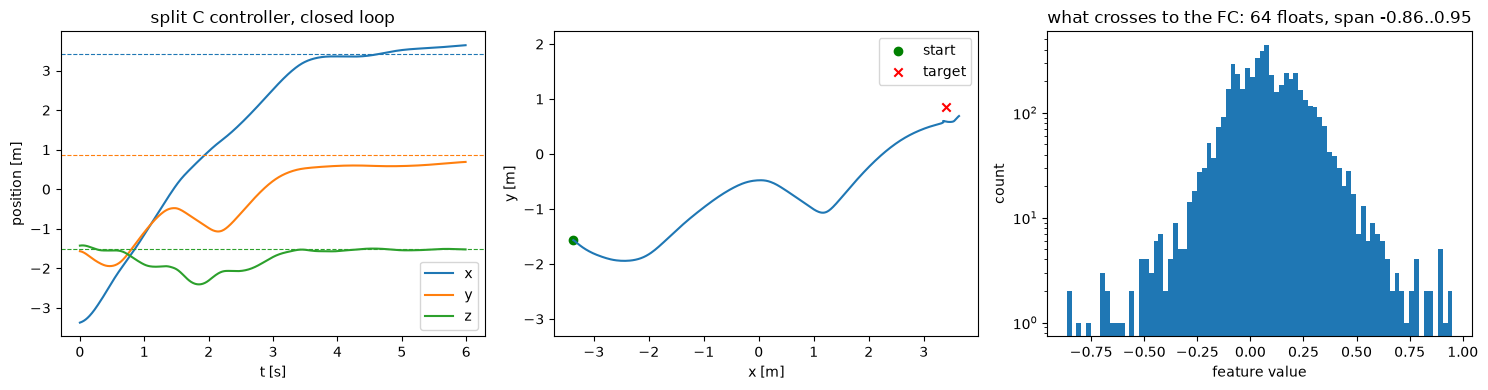

In [15]:
# Flown trajectory under the split C controller
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
t = np.arange(len(traj)) * env.dt
for i, lbl in enumerate('xyz'):
    ax[0].plot(t, traj[:, i], label=lbl)
    ax[0].axhline(target[i], ls='--', lw=0.8, color=f'C{i}')
ax[0].set_xlabel('t [s]'); ax[0].set_ylabel('position [m]')
ax[0].legend(); ax[0].set_title('split C controller, closed loop')

ax[1].plot(traj[:, 0], traj[:, 1])
ax[1].scatter(*traj[0, :2], marker='o', color='g', label='start')
ax[1].scatter(*target[:2], marker='x', color='r', label='target')
ax[1].set_xlabel('x [m]'); ax[1].set_ylabel('y [m]'); ax[1].axis('equal'); ax[1].legend()

ax[2].hist(cal_feats.reshape(-1), bins=80)
ax[2].set_yscale('log')
ax[2].set_xlabel('feature value'); ax[2].set_ylabel('count')
ax[2].set_title(f'what crosses to the FC: {proj_dim} floats, span '
                f'{cal_feats.min():.2f}..{cal_feats.max():.2f}')
plt.tight_layout(); plt.show()

## Integrating

The transport between these two is yours. The interface is one vector of
`CNN_FEATURE_DIM` floats per camera frame.

### Companion computer

```c
#include "cnn_encoder.h"

void on_depth_frame(const uint16_t* depth_mm)   // CNN_RAW_H x CNN_RAW_W
{
    float features[CNN_FEATURE_DIM];
    cnn_encode_frame(depth_mm, features);       // preprocess + CNN

    your_link_send(features, CNN_FEATURE_DIM);  // 64 floats, 256 B, once per frame
}
```

Latency matters more than throughput here: the FC always uses whatever arrived last, so an
encode-plus-transmit that overruns one camera period means the drone is flying on depth two
frames old rather than one. Budget against `NN_FEATURE_MAX_AGE`, and carry a capture
timestamp in your own framing so the first flights can measure the real end-to-end delay
rather than trust the budget.

### Flight controller

```c
#include "nn_controller.h"

static bool nn_was_active = false;

void yourLinkReceive(const float* features)   // your receive path, already validated
{
    nn_set_features(features);                // resets the age counter
}

void nnControllerUpdate(timeUs_t currentTimeUs)
{
    bool nn_active = FLIGHT_MODE(NN_MODE);   // whatever gates the mode

    if (nn_active && !nn_was_active) {
        nn_reset();          // rising edge: waypoint index, GRU hidden state, features
    }
    nn_was_active = nn_active;

    if (!nn_active) {
        return;              // never call nn_control() here: the GRU would integrate
    }                        // state for actions the drone never executed

    float world_state[16];
    /* fill from the EKF / RPM telemetry, NED, rad, rad/s */
    float motor_cmds[4];
    int status = nn_control(world_state, motor_cmds);

    if (status == NN_STATUS_STALE) {
        /* The depth information is older than NN_FEATURE_MAX_AGE. The commands are
           still meaningful -- the drone is flying on the last obstacle field it saw --
           but it is blind to anything new. Failsafe policy is yours: hold, descend,
           or hand back to the pilot. */
    }
    /* write motor_cmds (0..1) to the motor outputs */
}
```

`nn_set_features()` is a `memcpy` into the controller's buffer. It is safe to call from
your link task on a single-core FC where the control ISR cannot preempt it mid-copy. If
yours can, double buffer the vector or move the copy into the control loop — a vector torn
between two frames is a scene that never existed.

### Checklist before flying

- `motor_order[]` matches the indiflight mixer.
- `MOTOR_OMEGA_SCALE` set to `2*M_PI/60` if the FC reports RPM rather than rad/s.
- The EKF's position/heading origin matches the training frame, or `WORLD_YAW_OFFSET`
  compensates.
- The camera is cropped to `CNN_FOV_DEG` and downsampled to `CNN_RAW_H x CNN_RAW_W`, in
  metres/millimetres, with the same body mounting the renderer assumed. Check a handful of
  frames against `env.get_vis_depth` on the same scene before trusting it — this is the
  step with no error signal of its own.
- `CNN_INVALID_IS_FAR` matches what your sensor does with invalid pixels. The default (0)
  reads them as "obstacle in your face", which is safe but will make a noisy sensor refuse
  to fly.
- Both halves regenerated from the **same** run of this notebook. Nothing checks this at
  compile time any more — the two folders share no header — and mismatched halves produce
  a plausible-looking feature vector rather than an error.
- First flights with the link deliberately healthy, logging `nn_features_age()` and the
  `nn_control()` status each step, so the real frame cadence is measured rather than
  assumed.